# MovieIQ — Predictive Analytics on Film Success

Complete assessment solution using the supplied `movies.csv` dataset.

## STAGE 0 — Problem Statement

### 1. Definition of success
A movie is successful when `revenue > budget`. The target is `success`: 1 for successful and 0 for unsuccessful.

### 2. Why prediction is valuable
Studios can use predictions for production, marketing and release decisions. Investors can use them to assess potential financial risk.

### 3. Objective
Analyse historical movie performance, test relationships with success, train a binary classifier, and deploy the result in Streamlit.

### 4. Why classification?
The target has two discrete classes: successful and unsuccessful, so this is binary classification.

## STAGE 1 — Data Preparation

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("movies.csv")
print("Shape:", df.shape)
display(df.head())
display(df.describe(include="all").T)

Shape: (2000, 7)


,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
budget,2000.0,NaN,NaN,NaN,101921134.398,56827954.445757,1070640.0,52748322.25,102602308.5,150796203.75,199987907.0
revenue,2000.0,NaN,NaN,NaN,178057426.1405,129387926.693274,1138729.0,74583058.75,148488152.5,262367860.25,574490131.0
popularity,2000.0,NaN,NaN,NaN,50.090738,28.482104,1.018466,25.720784,50.210396,74.925354,99.764659
runtime,2000.0,NaN,NaN,NaN,129.568,28.906507,80.0,104.0,130.0,155.0,179.0
vote_average,2000.0,NaN,NaN,NaN,6.036764,1.743093,3.008133,4.583298,6.052901,7.577305,8.998509
title,2000,2000,Movie 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,2000,10,"[{'id': 10749, 'name': 'Romance'}]",220,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Missing values:")
display(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Zero budget:", (df.budget == 0).sum())
print("Zero revenue:", (df.revenue == 0).sum())

Missing values:


budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64

Duplicate rows: 0
Zero budget: 0
Zero revenue: 0


In [4]:
numeric = ["budget","revenue","popularity","runtime","vote_average"]
for c in numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.drop_duplicates()
df = df[(df["budget"] > 0) & (df["revenue"] > 0)]
df = df.dropna(subset=numeric).copy()

df["success"] = (df["revenue"] > df["budget"]).astype(int)

print("Cleaned shape:", df.shape)
print("Success counts:")
display(df["success"].value_counts())
print("Success percentages:")
display(df["success"].value_counts(normalize=True).mul(100).rename("percent"))

Cleaned shape: (2000, 8)
Success counts:


success
1    1614
0     386
Name: count, dtype: int64

Success percentages:


success
1    80.7
0    19.3
Name: percent, dtype: float64

### Handling zero values
Zero budget/revenue values are excluded because the success definition directly compares revenue with budget. Treating unavailable financial values as real zeros could create misleading target labels.

### Genre processing
Genres are multi-value text. They are split and exploded so that genre-level counts and success rates can be analysed.

In [5]:
import ast

def parse_genres(x):
    # `genres` is a stringified list of TMDB dicts, e.g. "[{'id': 18, 'name': 'Drama'}]".
    # A comma/pipe split shreds this into fragments; ast.literal_eval parses it correctly.
    try:
        parsed = ast.literal_eval(x)
        names = [g["name"] for g in parsed]
        return names if names else ["Unknown"]
    except (ValueError, SyntaxError, TypeError):
        return ["Unknown"]

df["genre_list"] = df["genres"].fillna("[]").apply(parse_genres)
genre_df = df.explode("genre_list").rename(columns={"genre_list":"genre"})
display(genre_df[["title","genre","success"]].head())

,title,genre,success
0,Movie 1,Romance,1
1,Movie 2,Drama,1
2,Movie 3,Comedy,1
3,Movie 4,Drama,0
4,Movie 5,Comedy,1


## STAGE 2 — Exploratory Data Analysis

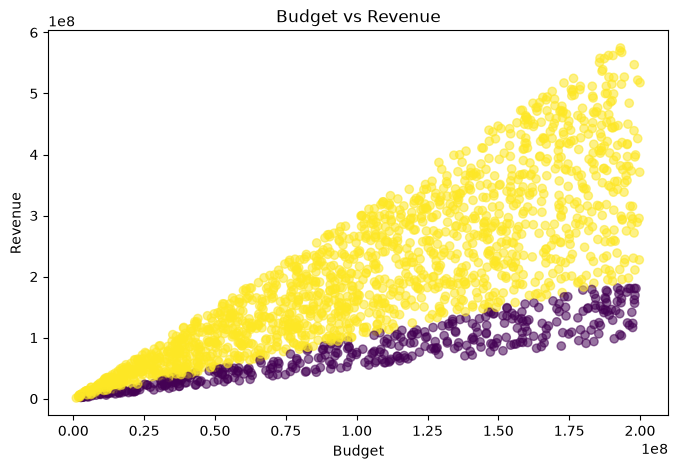

Budget-revenue correlation: 0.759848103622043


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.scatter(df["budget"], df["revenue"], c=df["success"], alpha=.55)
plt.xlabel("Budget"); plt.ylabel("Revenue"); plt.title("Budget vs Revenue")
plt.show()

print("Budget-revenue correlation:", df["budget"].corr(df["revenue"]))

In [7]:
genre_summary = genre_df.groupby("genre").agg(
    movie_count=("title","count"),
    success_rate=("success","mean")
).sort_values("movie_count",ascending=False)
display(genre_summary.head(10))

,movie_count,success_rate
genre,,
Romance,220,0.809091
Adventure,207,0.801932
Science Fiction,205,0.785366
Animation,203,0.812808
Comedy,202,0.811881
Horror,199,0.819095
Drama,197,0.822335
Thriller,194,0.809278
Action,192,0.786458


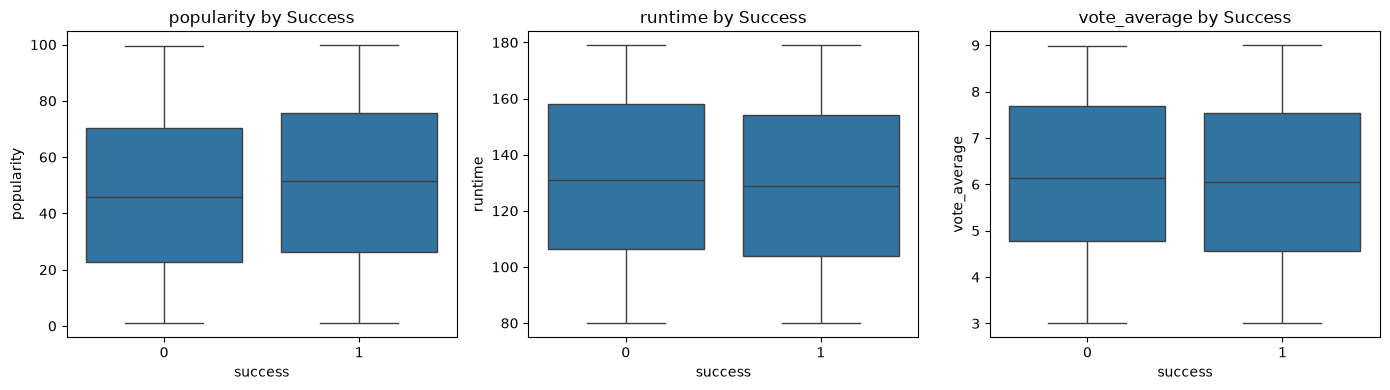

In [8]:
fig,ax=plt.subplots(1,3,figsize=(14,4))
for a,c in zip(ax,["popularity","runtime","vote_average"]):
    sns.boxplot(data=df,x="success",y=c,ax=a)
    a.set_title(f"{c} by Success")
plt.tight_layout()
plt.show()

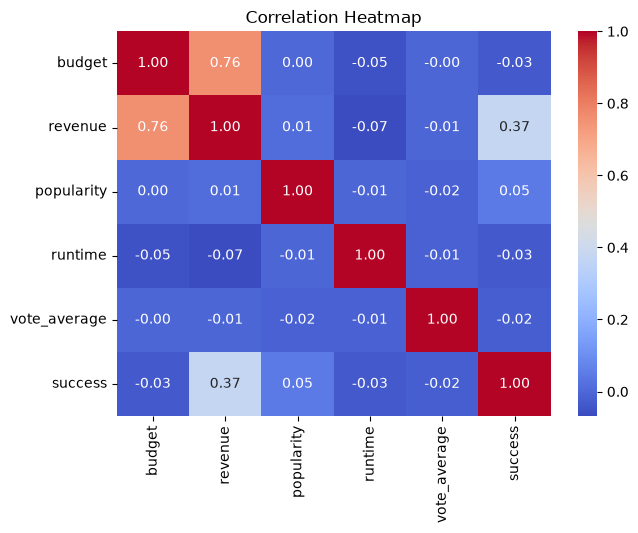

In [9]:
corr=df[["budget","revenue","popularity","runtime","vote_average","success"]].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Revenue is excluded from the model because it is used to construct `success`. Using revenue as a feature would leak the target definition into the model.

## STAGE 3 — Statistical Testing

In [10]:
from scipy import stats

successful=df.loc[df.success==1,"popularity"]
unsuccessful=df.loc[df.success==0,"popularity"]

t_stat,t_p=stats.ttest_ind(successful,unsuccessful,equal_var=False,nan_policy="omit")
print("H0: mean popularity is the same between successful and unsuccessful movies.")
print("H1: the means differ.")
print("t-statistic:",t_stat)
print("p-value:",t_p)
print("Decision:", "Reject H0" if t_p < .05 else "Fail to reject H0")

H0: mean popularity is the same between successful and unsuccessful movies.
H1: the means differ.
t-statistic: 2.0616702513558818
p-value: 0.039682444907920326
Decision: Reject H0


In [11]:
contingency=pd.crosstab(genre_df["genre"],genre_df["success"])
chi2,chi_p,dof,expected=stats.chi2_contingency(contingency)

print("H0: genre and success are independent.")
print("H1: genre and success are associated.")
print("Chi-square:",chi2)
print("Degrees of freedom:",dof)
print("p-value:",chi_p)
print("Decision:", "Reject H0" if chi_p < .05 else "Fail to reject H0")

H0: genre and success are independent.
H1: genre and success are associated.
Chi-square: 1.7730811979406715
Degrees of freedom: 9
p-value: 0.9945690204257113
Decision: Fail to reject H0


### What is a p-value?
A p-value measures how compatible the observed result is with the null hypothesis. At α = 0.05, p < 0.05 is commonly treated as statistically significant. Statistical significance does not establish causation.

## STAGE 4 — Predictive Modeling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

features=["budget","popularity","runtime","vote_average"]
X=df[features]
y=df["success"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.20,random_state=42,stratify=y
)

model=RandomForestClassifier(
    n_estimators=300,random_state=42,class_weight="balanced"
)
model.fit(X_train,y_train)
pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred,zero_division=0))
print("Recall:",recall_score(y_test,pred,zero_division=0))
print(classification_report(y_test,pred,zero_division=0))

Accuracy: 0.7475
Precision: 0.8100558659217877
Recall: 0.8978328173374613
              precision    recall  f1-score   support

           0       0.21      0.12      0.15        77
           1       0.81      0.90      0.85       323

    accuracy                           0.75       400
   macro avg       0.51      0.51      0.50       400
weighted avg       0.70      0.75      0.72       400



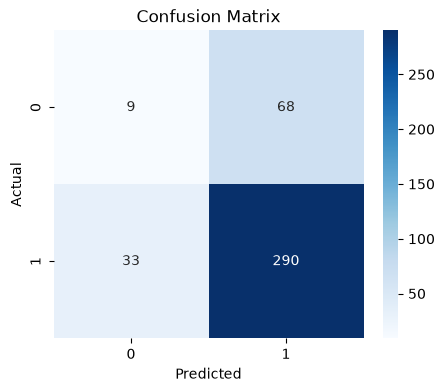

TN, FP, FN, TP: [  9  68  33 290]


In [13]:
cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["0","1"],yticklabels=["0","1"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print("TN, FP, FN, TP:",cm.ravel())

popularity      0.264536
vote_average    0.260528
budget          0.255198
runtime         0.219738
dtype: float64

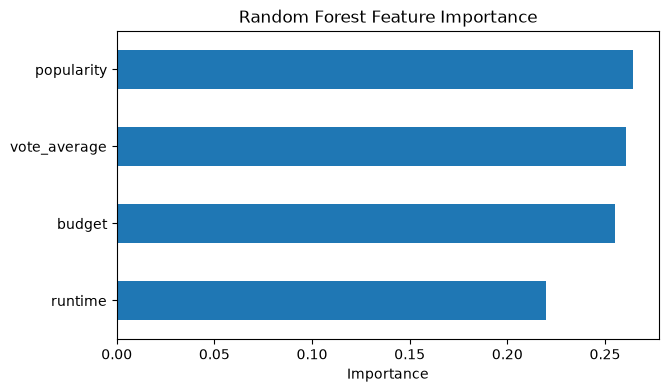

In [14]:
importance=pd.Series(model.feature_importances_,index=features).sort_values(ascending=False)
display(importance)
importance.sort_values().plot(kind="barh",figsize=(7,4),title="Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

### Model interpretation
Random Forest combines many decision trees. The model's feature-importance scores indicate which available predictors contribute most to its decisions.

Because the target is imbalanced, accuracy should not be considered alone. Precision, recall and the confusion matrix are also required.

## STAGE 5 — Streamlit Dashboard

Run:

```bash
pip install -r requirements.txt
streamlit run MovieIQ.py
```

The dashboard provides genre and vote-average filters, EDA visualizations, statistical-test information, and an interactive success predictor.

## Reflection and Limitations

The model is a decision-support tool, not a guarantee. The dataset does not include factors such as marketing expenditure, cast, franchise strength, release timing, competition and distribution. The target is also imbalanced toward successful movies.

Future work could add richer pre-release features, cross-validation, hyperparameter tuning, probability calibration and alternative classifiers.